In [145]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import nifty8 as ift
import numpy as np
import resolve as rve

from jax.lax import slice as jax_slice
from scipy.signal import convolve

from aim_resolve import Observation, SignalSpace, plot_arrays, check_type

jax.config.update("jax_enable_x64", True)

In [146]:
def build_exact_responses(obs, space):
    check_type(space, SignalSpace)
    sdom = ift.RGSpace(space.shape, distances=space.distances)
    sky_dom = rve.default_sky_domain(sdom=sdom)
    R = rve.InterferometryResponse(obs, sky_dom, True, 1e-9, verbosity=0, nthreads=8)

    space_l = space.multiply_fov(2)
    sdom_l = ift.RGSpace(space_l.shape, distances=space_l.distances)
    sky_dom_l = rve.default_sky_domain(sdom=sdom_l)
    R_l = rve.InterferometryResponse(obs, sky_dom_l, True, 1e-9, verbosity=0, nthreads=8)

    dch_l = ift.DomainChangerAndReshaper(R_l.domain[3], R_l.domain)
    R_l = R_l @ dch_l
    dch = ift.DomainChangerAndReshaper(R.domain[3], R.domain)
    R = R @ dch

    N_inv = ift.DiagonalOperator(obs.weight)
    RNR = R.adjoint @ N_inv @ R
    RNR_l = R_l.adjoint @ N_inv @ R_l

    return R, R_l, RNR, RNR_l


def compute_psf_kernel(RNR_l):
    dom_l = RNR_l.domain
    shp_l = dom_l.shape

    delta = np.zeros(shp_l)
    delta[shp_l[0]//2, shp_l[1]//2] = 1 / dom_l.scalar_weight()
    delta = ift.makeField(dom_l, delta)
    kernel = RNR_l(delta)

    return kernel.val


def compute_noise_kernel(RNR, relativ_min_val=0.):
    '''Build the inverse noise kernel for the given RNR operator.'''
    dom = RNR.domain
    shp = dom.shape
    FFT = ift.FFTOperator(RNR.domain)

    delta = np.zeros(shp)
    delta[shp[0]//2, shp[1]//2] = 1 / dom.scalar_weight()
    delta = ift.makeField(dom, delta)
    kernel = RNR(delta).val
    kernel = np.roll(kernel, -shp[0]//2, axis=0)
    kernel = np.roll(kernel, -shp[1]//2, axis=1)
    kernel = ift.makeField(RNR.target, kernel)
    FFT = ift.FFTOperator(RNR.domain)
    max_val = np.max(FFT(kernel).abs().val)
    min_val = relativ_min_val * max_val
    min_val = ift.full(FFT.target, min_val)
    min_val_adder = ift.Adder(min_val)

    pos_eig_val = ift.Operator.identity_operator(FFT.target).exp()
    pos_eig_val = min_val_adder @ pos_eig_val
    rls1 = ift.Realizer(pos_eig_val.target)
    rls2 = ift.Realizer(FFT.domain)

    kernel_pos = rls2 @ FFT.inverse @ rls1.adjoint @ pos_eig_val

    cov = ift.ScalingOperator(kernel_pos.target, 1e-2*max_val)
    lh = ift.GaussianEnergy(data=kernel, inverse_covariance=cov.inverse) @ kernel_pos
    init_pos = (FFT(kernel) - min_val).abs().log()
    energy = ift.EnergyAdapter(position=init_pos, op=lh, want_metric=True)

    ic_newton = ift.DeltaEnergyController(name='Newton', iteration_limit=80, tol_rel_deltaE=0)
    minimizer = ift.NewtonCG(ic_newton)
    res = minimizer(energy)[0].position

    return pos_eig_val(res).val


def fft_fun(space):
    check_type(space, SignalSpace)
    dvol = space.dis.prod()
    print('dvol:', dvol)
    return lambda x: dvol * jnp.fft.fftn(x)


def ifft_fun(space):
    check_type(space, SignalSpace)
    dvol = 1. / (space.shp * space.dis).prod()
    print('dvol:', dvol)
    npix = space.size
    print('npix:', npix)
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def shift_kernel(kernel):
    shifted_kernel = np.roll(kernel, -kernel.shape[0]//2, axis=0)
    shifted_kernel = np.roll(shifted_kernel, -kernel.shape[1]//2, axis=1)
    return shifted_kernel


def downsample(array, factor):
    if factor == 1:
        return array
    if factor in (2,4,8):
        return array.reshape(-1, factor).mean(axis=1)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')
    
def upsample(array, factor):
    if factor == 1:
        return array
    elif factor in (2, 4, 8):
        return array.repeat(factor)
    else:
        raise ValueError(f'Invalid zoom factor: {factor}')


def plot_1d(*arrays, figsize=(5,2), norm='linear', title='',
            offset=1, vmin=None, vmax=None, cmap='Paired'):
    plt.figure(figsize=figsize)
    colors = plt.colormaps.get_cmap(cmap)

    if norm == 'log':
        min_a = min([a[a > 0].min() for a in arrays if np.any(a > 0)])
    for i, a in enumerate(arrays):
        if a.size != arrays[0].size:
            raise ValueError("All arrays must have the same size")
        a = np.array(a)
        if norm == 'log':
            a[a <= 0] = min_a
        if offset:
            a = a[offset:-offset]
        plt.plot(np.arange(a.size), a, color=colors(i))

    plt.yscale(norm)
    if vmin is not None or vmax is not None:
        plt.ylim(vmin, vmax)
    plt.title(title)
    plt.show()

In [3]:
obs = Observation.load('/Users/rf/Development/data/eso_986-1137mhz.npz')
obs = obs.to_double_precision()
obs = obs.to_resolve_obs()
print(obs)

Observation:
  Source name:		None
  Visibilities shape:	(1, 3668965, 7)
  # visibilities:	25682755
  Frequency range:	986.720 -- 1137.188 MHz
  Polarizations:	I
  Shortest baseline:	0.0 m -> inf deg
  Longest baseline:	7697.6 m -> 7.064 arcsec
  Flagged:		38.1%


/Users/rf/miniforge3/envs/aim/lib/python3.11/site-packages/resolve/data/observation.py:754: RuntimeWarning: divide by zero encountered in scalar divide
  short1 = 1/(short0*self.freq.min()/SPEEDOFLIGHT)


SignalSpace(shape=(512, 512), distances=(3.408846195301425e-05, 3.408846195301425e-05), center=(0.0, 0.0), rotation=0.0)


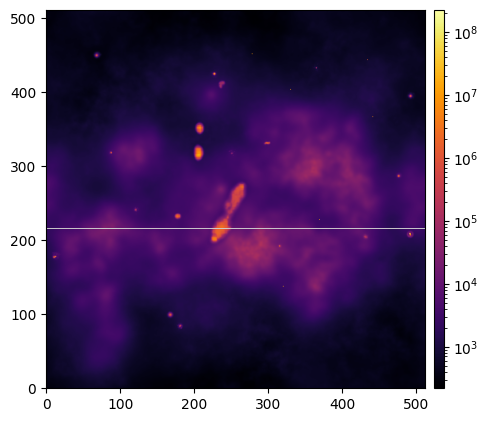

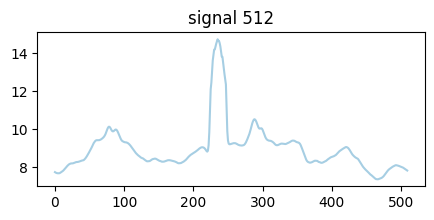

In [4]:
fname = '/Users/rf/Development/packages/aim-resolve/steering/runs/fast_vi_512c/files/5_rec.pkl'
sky_2d_512 = np.load(fname, allow_pickle=True)[0]
space_2d_512 = SignalSpace.build(shape=sky_2d_512.shape, fov=('1deg', '1deg'))
print(space_2d_512)

slc = 215 #207
signal_slc = sky_2d_512.copy()
signal_slc[:, slc] = np.nan
plot_arrays(signal_slc, norm='log', dpi=100)

sky_1d_512 = sky_2d_512[:, slc]

sky_1d_512 = np.log(sky_1d_512)
plot_1d(sky_1d_512, norm='linear', title='signal 512')

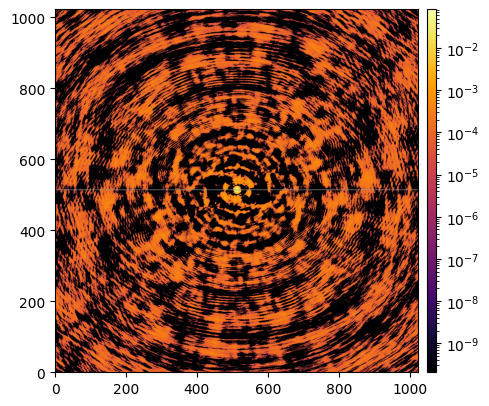

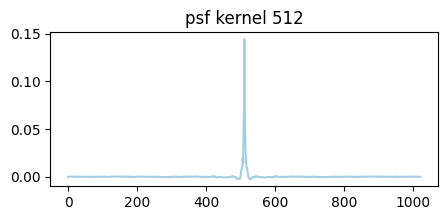

In [5]:
R, R_l, RNR, RNR_l = build_exact_responses(obs, space_2d_512)

psf_kernel_2d_512 = compute_psf_kernel(RNR_l)

slc = 512 #207
psf_kernel_slc = psf_kernel_2d_512.copy()
psf_kernel_slc[:, slc] = np.nan
plot_arrays(psf_kernel_slc, norm='log', dpi=100)

psf_kernel_1d_512 = psf_kernel_2d_512[:, slc]
plot_1d(psf_kernel_1d_512, norm='linear', title='psf kernel 512')

In [147]:
signal_bg = np.log(sky_2d_512[140, :])

peak = sky_2d_512[:, 215]
peak = np.log(peak) - 9.5
peak = np.where(peak > 0, peak, 0)
# plot_1d(peak)

slc_t0 = slice(200, 264)
signal_t0 = np.zeros_like(peak)
signal_t0[slc_t0] = peak[200:264]
signal_t0 = signal_t0 * 1

slc_t1 = slice(270, 334)
signal_t1 = np.zeros_like(peak)
signal_t1[slc_t1] = peak[260:324]
signal_t1 = signal_t1 * 3

idx_p0 = 400
ps_ker = 15
signal_p0 = np.zeros_like(peak)
signal_p0[idx_p0] = 7

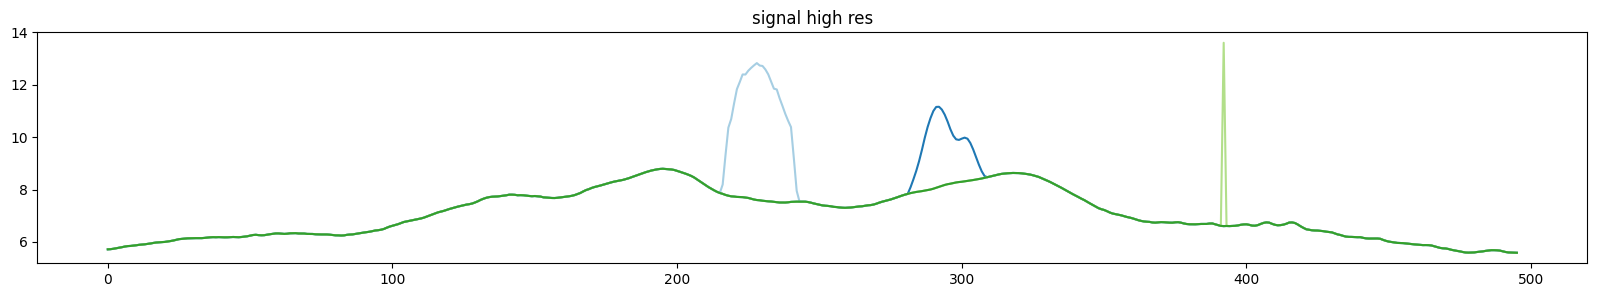

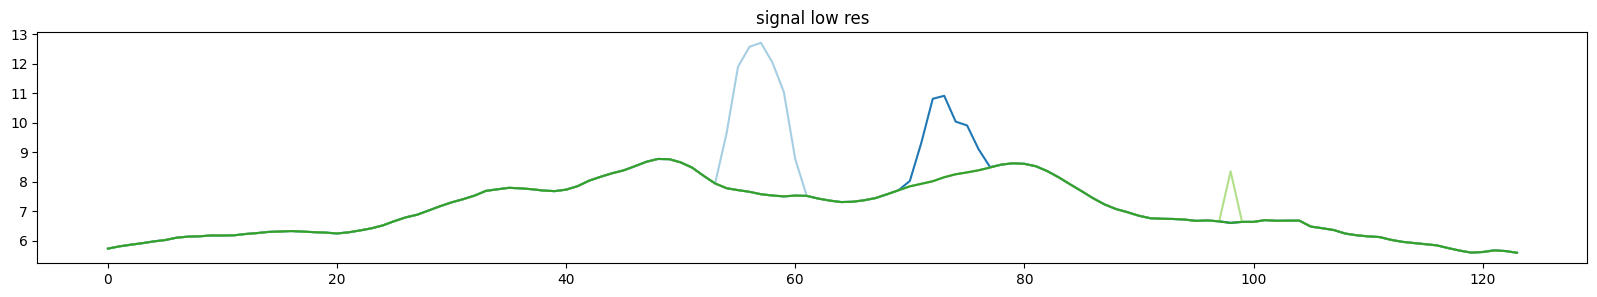

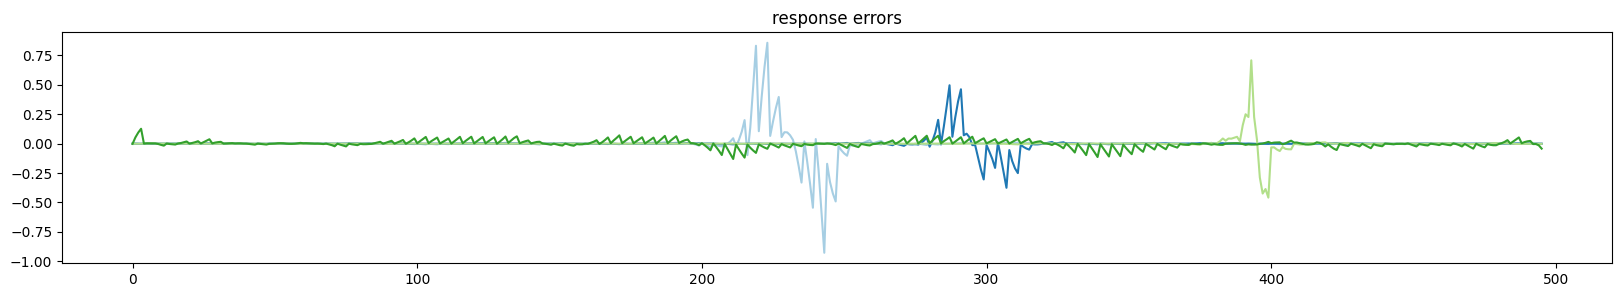

In [149]:
zoom = 4

signal_dict = {
    'sum': {'val': signal_bg + signal_t0 + signal_t1 + signal_p0, 'low': downsample(signal_bg + signal_t0 + signal_t1 + signal_p0, zoom)},
    't0': {'val': signal_t0, 'low': downsample(signal_t0, zoom), 'slc': slc_t0, 'slc_low': slice(slc_t0.start//zoom, slc_t0.stop//zoom)},
    't1': {'val': signal_t1, 'low': downsample(signal_t1, zoom), 'slc': slc_t1, 'slc_low': slice(slc_t1.start//zoom, slc_t1.stop//zoom)},
    'ps': {'val': signal_p0, 'low': downsample(signal_p0, zoom), 'idx': idx_p0, 'ker_pix': 32},
    'bg': {'val': signal_bg, 'low': downsample(signal_bg, zoom)},
    'fac': zoom,
    'shp': signal_bg.size,
}
kernel = psf_kernel_1d_512.copy()

plot_1d(*[signal_dict['bg']['val'] + sig['val'] for k,sig in signal_dict.items() if k in ['t0','t1','ps']], signal_dict['bg']['val'], norm='linear', offset=8, figsize=(20,3), title='signal high res')
plot_1d(*[signal_dict['bg']['low'] + sig['low'] for k,sig in signal_dict.items() if k in ['t0','t1','ps']], signal_dict['bg']['low'], norm='linear', offset=8//zoom, figsize=(20,3), title='signal low res')

rsp_err = []
low_res_err = np.zeros(signal_dict['shp'])
ker_low = downsample(kernel, zoom)
for k,sig in signal_dict.items():
    if isinstance(sig, dict) and k != 'sum':
        rsp_low = convolve(sig['low'], ker_low, mode='same') * zoom
        rsp_low = upsample(rsp_low, zoom)
        rsp_val = convolve(sig['val'], kernel, mode='same')
        rsp_err += [rsp_val - rsp_low, ]

        if 'bg' in k:
            low_res_err += rsp_val - rsp_low
        if 't' in k:
            sig_box = np.ones(signal_dict['shp'])
            sig_box[sig['slc']] = 0
            low_res_err += (rsp_val - rsp_low) * sig_box
        if 'ps' in k:
            sig_box = np.ones(signal_dict['shp'])
            sig_box[sig['idx']-sig['ker_pix']//2:sig['idx']+sig['ker_pix']//2] = 0
            low_res_err += (rsp_val - rsp_low) * sig_box


plot_1d(*rsp_err, norm='linear', offset=8, figsize=(20,3), title='response errors')


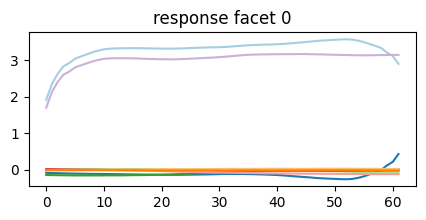

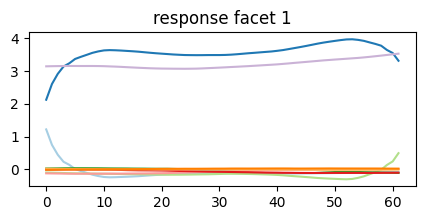

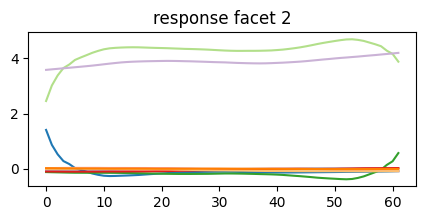

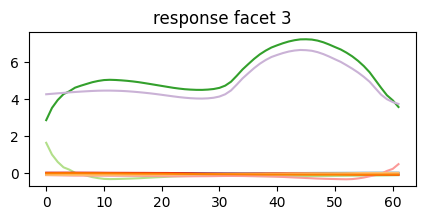

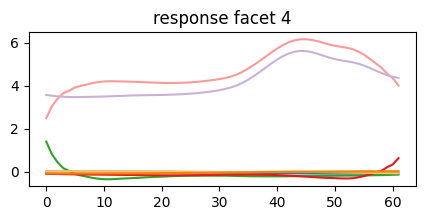

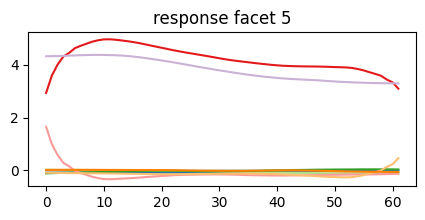

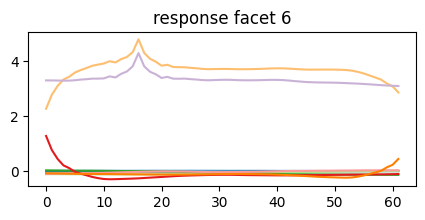

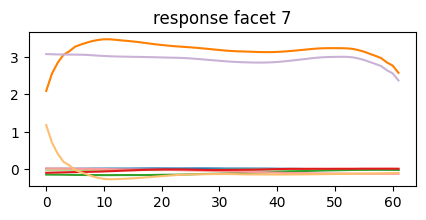

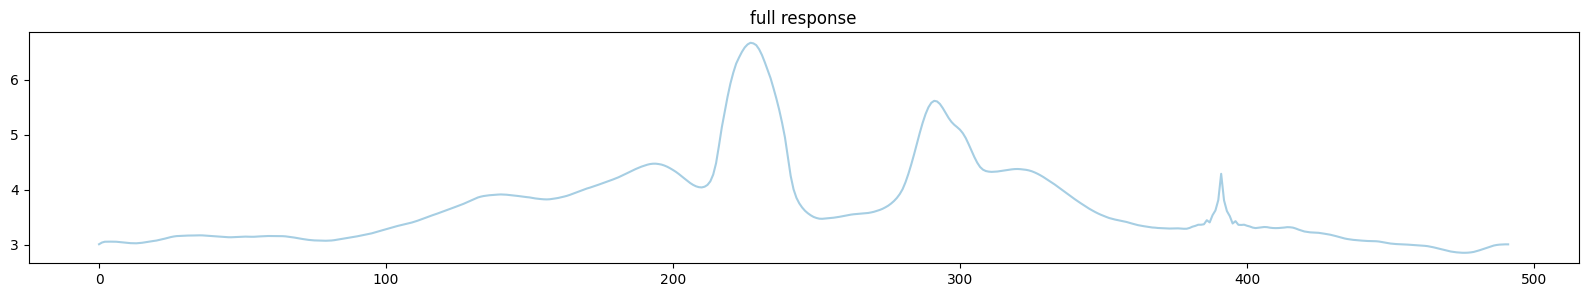

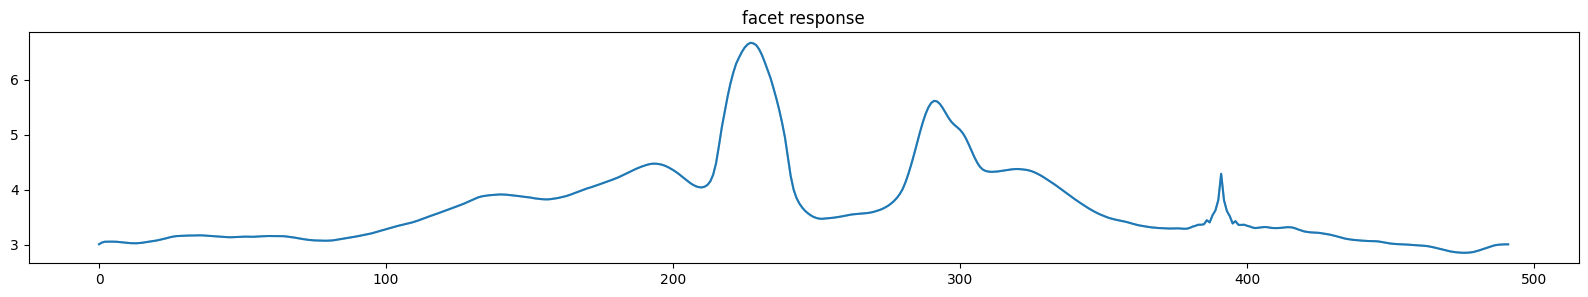

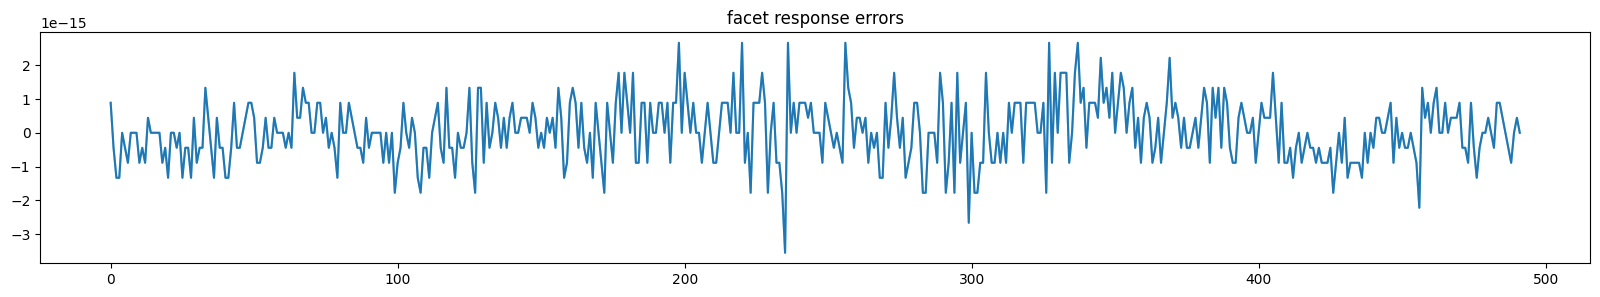

In [153]:
def crop_kernel(kernel, factor):
    return kernel[kernel.size//2 - kernel.size//(2*factor) : kernel.size//2 + kernel.size//(2*factor)]


def shift_kernel(kernel, pixels):
    return np.roll(kernel, pixels)


def facet_convolve(signal, kernel, facets=4):

    split_size = signal.size // facets
    signal_split = signal.reshape(facets, split_size)
    kernel_center = crop_kernel(kernel, facets)

    response_split = np.zeros_like(signal_split)

    for i in range(facets):
        rsp = np.zeros_like(signal_split)

        rsp[i] = convolve(signal_split[i], kernel_center, mode='same', method='fft')

        for j in range(facets):
            if j != i:
                kernel_sub = crop_kernel(shift_kernel(kernel, (j - i) * split_size), facets)

                rsp[j] = convolve(signal_split[j], kernel_sub, mode='same', method='fft')

        rsp_sum = rsp.sum(axis=0)

        plot_1d(*[rsp[k] for k in range(facets)], rsp_sum, title=f'response facet {i}')

        response_split[i] = rsp_sum

    return response_split.reshape(-1)


response_full = convolve(signal_dict['sum']['val'], kernel, mode='same', method='fft')

response_facet = facet_convolve(signal_dict['sum']['val'], kernel, 8)

plot_1d(response_full, offset=10, figsize=(20,3), title='full response')
plot_1d(response_full, response_facet, offset=10, figsize=(20,3), title='facet response')

plot_1d(*[response_full - response_facet] * 2, offset=10, figsize=(20,3), title='facet response errors')

SignalSpace(shape=(512, 512), distances=(6.81769239060285e-05, 6.81769239060285e-05), center=(0.0, 0.0), rotation=0.0)


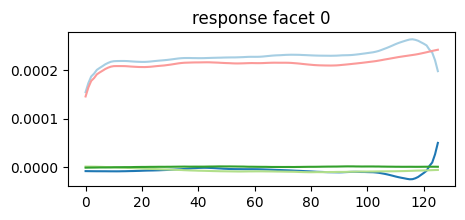

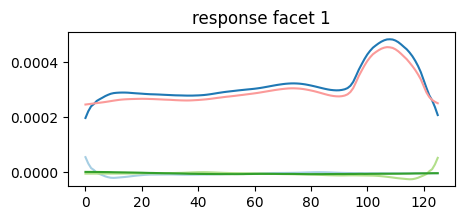

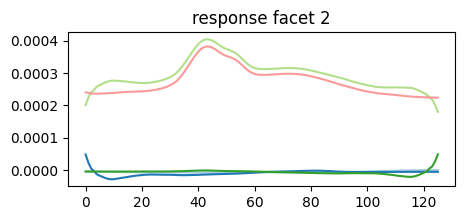

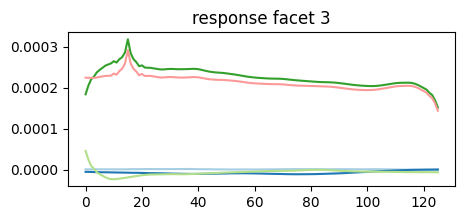

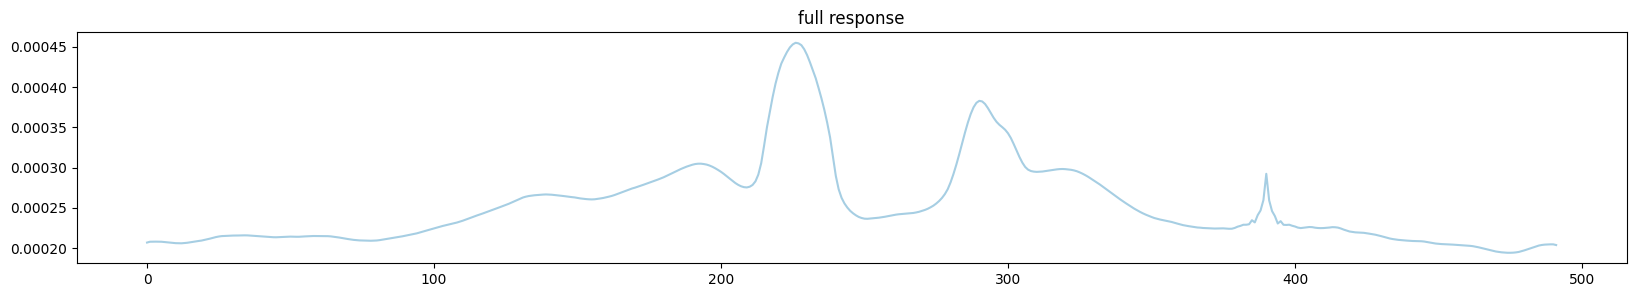

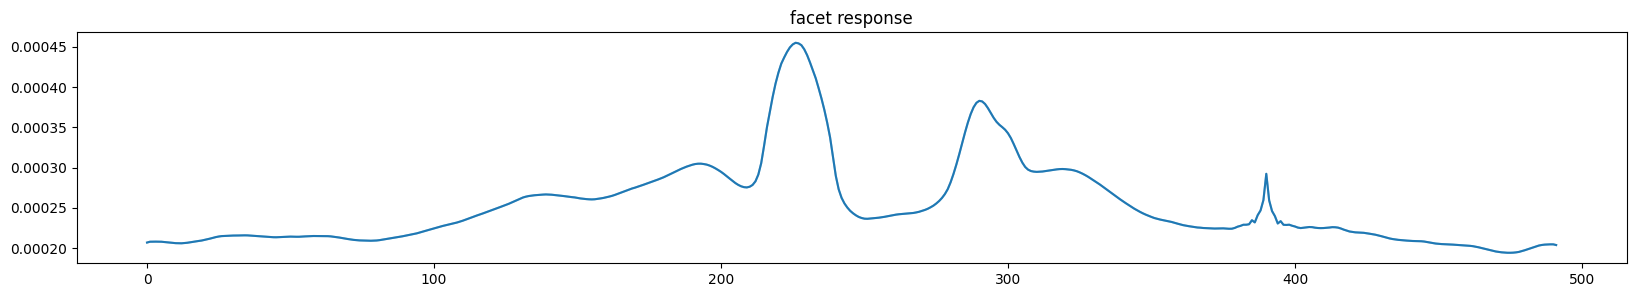

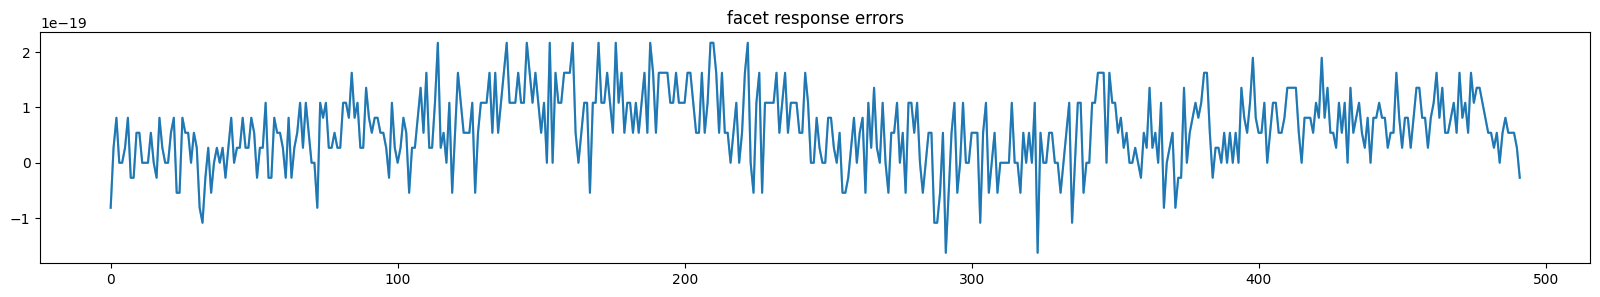

In [165]:
def fft_fun(space):
    check_type(space, SignalSpace)
    dvol = space.dis[0]
    return lambda x: dvol * jnp.fft.fftn(x)


def ifft_fun(space):
    check_type(space, SignalSpace)
    dvol = 1. / (space.shp[0] * space.dis[0])
    npix = space.shape[0]
    return lambda x: dvol * npix * jnp.fft.ifftn(x)


def shift_kernel(kernel, pixels):
    return np.roll(kernel, pixels)


def fft_kernel(kernel, space):
    kernel = shift_kernel(kernel, -kernel.shape[0]//2)
    space_l = space.multiply_fov(2)
    fft_kernel = fft_fun(space_l)(kernel)
    return fft_kernel


def fft_convolve(kernel, space):
    space_l = space.multiply_fov(2)
    kernel = jnp.array(fft_kernel(kernel, space))

    fft_l = fft_fun(space_l)
    ifft_l = ifft_fun(space_l)
    shape = int(space.shp[0])
    padding = shape // 2

    def fft_conv(x):
        res = jnp.pad(x, 2 * (padding,))
        res = ifft_l(kernel * fft_l(res)).real
        res = jax_slice(res, (padding,), (padding + shape,))
        return np.array(res)

    return fft_conv


def crop_kernel(kernel, factor):
    return kernel[kernel.size//2 - kernel.size//(2*factor) : kernel.size//2 + kernel.size//(2*factor)]


def facet_convolve(signal, kernel, space, facets=4):

    split_size = signal.size // facets
    signal_split = signal.reshape(facets, split_size)
    kernel_center = crop_kernel(kernel, facets)

    response_split = np.zeros_like(signal_split)

    for i in range(facets):
        rsp = np.zeros_like(signal_split)

        rsp[i] = fft_convolve(kernel_center, space.multiply_fov(1/facets))(signal_split[i])

        for j in range(facets):
            if j != i:
                kernel_sub = crop_kernel(shift_kernel(kernel, (j - i) * split_size), facets)

                rsp[j] = fft_convolve(kernel_sub, space.multiply_fov(1/facets))(signal_split[j])

        rsp_sum = rsp.sum(axis=0)

        plot_1d(*[rsp[k] for k in range(facets)], rsp_sum, title=f'response facet {i}')

        response_split[i] = rsp_sum

    return response_split.reshape(-1)


space = SignalSpace.build(shape=(signal_dict['shp'], signal_dict['shp']), fov=('2deg', '2deg'))
print(space)

response_full = fft_convolve(kernel, space)(signal_dict['sum']['val'])

response_facet = facet_convolve(signal_dict['sum']['val'], kernel, space, 4)

plot_1d(response_full, offset=10, figsize=(20,3), title='full response')
plot_1d(response_full, response_facet, offset=10, figsize=(20,3), title='facet response')

plot_1d(*[response_full - response_facet] * 2, offset=10, figsize=(20,3), title='facet response errors')